<a href="https://colab.research.google.com/github/isaacadebayo/Predictive-Analytics-Public-Datasets/blob/main/Apple_Stock_prediction_timeseries_split_fold4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
stocks = pd.read_csv('/content/drive/MyDrive/aapl_stock_prices.csv')
stocks.head()

,Date,Open,High,Low,Close,Volume
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600


# Feature Engineering

Moving average price

In [4]:
stocks['Moving_Average'] = stocks['Close'].rolling(window=50).mean()

stocks

,Date,Open,High,Low,Close,Volume,Moving_Average
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN
...,...,...,...,...,...,...,...
11402,2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650
11403,2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556
11404,2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839
11405,2026-03-17,252.960007,255.130005,252.179993,254.229996,32361600,261.874306


Difference in price

In [5]:
delta = stocks['Close'].diff()
delta

,Close
0,NaN
1,-0.005128
2,-0.006838
3,0.002137
4,0.002565
...,...
11402,-5.050003
11403,-5.639999
11404,2.700012
11405,1.409988


Separate calculated gain and losses

In [6]:
gain = delta.clip(lower=0)
loss = -1 * delta.clip(upper=0)

Calculate Exponential moving average

In [7]:
avg_gain = gain.ewm(com=14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(com=14, min_periods=14, adjust=False).mean()

avg_loss

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
11402,1.726921
11403,1.987793
11404,1.855273
11405,1.731588


In [8]:
rs = avg_gain / avg_loss
rsi = 100 - (100 / (1 + rs))

stocks['RSI'] = rsi
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
0,1980-12-12,0.098297,0.098725,0.098297,0.098297,469033600,NaN,NaN
1,1980-12-15,0.093597,0.093597,0.093169,0.093169,175884800,NaN,NaN
2,1980-12-16,0.086758,0.086758,0.086331,0.086331,105728000,NaN,NaN
3,1980-12-17,0.088468,0.088895,0.088468,0.088468,86441600,NaN,NaN
4,1980-12-18,0.091032,0.091460,0.091032,0.091032,73449600,NaN,NaN


Drop first 50 rows to incorporate moving average column and prevent skewing the data

In [9]:
stocks.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Moving_Average,49
RSI,14


In [10]:
stocks.drop(index=stocks.index[:50], inplace=True)
stocks.head()

,Date,Open,High,Low,Close,Volume,Moving_Average,RSI
50,1981-02-25,0.086331,0.086758,0.086331,0.086331,19488000,0.101298,38.088629
51,1981-02-26,0.087613,0.088040,0.087613,0.087613,10841600,0.101187,39.855881
52,1981-02-27,0.090605,0.091460,0.090605,0.090605,14761600,0.101272,43.863024
53,1981-03-02,0.091032,0.091460,0.091032,0.091032,11760000,0.101324,44.429548
54,1981-03-03,0.090178,0.090178,0.089750,0.089750,16172800,0.101298,43.033586


In [11]:
stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11357 entries, 50 to 11406
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            11357 non-null  object 
 1   Open            11357 non-null  float64
 2   High            11357 non-null  float64
 3   Low             11357 non-null  float64
 4   Close           11357 non-null  float64
 5   Volume          11357 non-null  int64  
 6   Moving_Average  11357 non-null  float64
 7   RSI             11357 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 709.9+ KB


<Axes: xlabel='Date'>

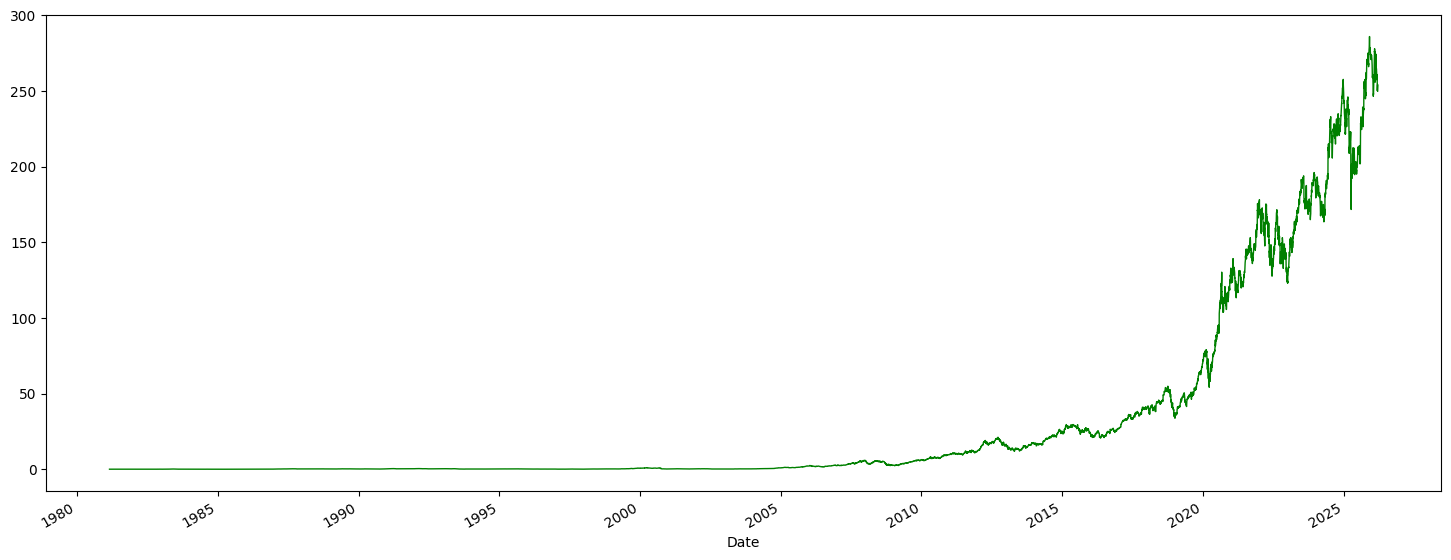

In [12]:
if 'Date' in stocks.columns:
    stocks['Date'] = pd.to_datetime(stocks['Date'])
    stocks = stocks.set_index('Date')
stocks.Close.plot(figsize=(18,7), linewidth=1, c='g')

In [14]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X, y = [], []
dates = []
for i in range(len(stocks) - window_size):
    X.append(stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y.append(stocks.iloc[i+window_size, 1])
    dates.append(stocks.index[i+window_size])

X = np.array(X)
y = np.array(y)
dates = np.array(dates)

print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (11347, 10, 7), y shape: (11347,)


In [15]:
# one temporal split, used by everyone
split_idx    = int(len(X) * 0.8)
X_train_3d   = X[:split_idx]       # for LSTM (3D)
X_test_3d    = X[split_idx:]
X_train_2d   = X_train_3d.reshape(X_train_3d.shape[0], -1)  # for sklearn + Dense
X_test_2d    = X_test_3d.reshape(X_test_3d.shape[0], -1)
y_train      = y[:split_idx]
y_test       = y[split_idx:]
dates_train  = dates[:split_idx]
dates_test   = dates[split_idx:]

print(f"Train: X={X_train_3d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_3d.shape}, y={y_test.shape}")
print(f"Train: X={X_train_2d.shape}, y={y_train.shape}")
print(f"Test:  X={X_test_2d.shape}, y={y_test.shape}")
print(f"Train: X={dates_train.shape}, y={y_train.shape}")
print(f"Test:  X={dates_test.shape}, y={y_test.shape}")


Train: X=(9077, 10, 7), y=(9077,)
Test:  X=(2270, 10, 7), y=(2270,)
Train: X=(9077, 70), y=(9077,)
Test:  X=(2270, 70), y=(2270,)
Train: X=(9077,), y=(9077,)
Test:  X=(2270,), y=(2270,)


In [16]:
from sklearn.preprocessing import MinMaxScaler
# one scaler, fit on train only, used by Keras pipelines
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_train_scaled_2d = scaler_X.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler_X.transform(X_test_2d)
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))
# reshape scaled 2D back to 3D
X_train_scaled_3d = X_train_scaled_2d.reshape(X_train_3d.shape)
X_test_scaled_3d  = X_test_scaled_2d.reshape(X_test_3d.shape)

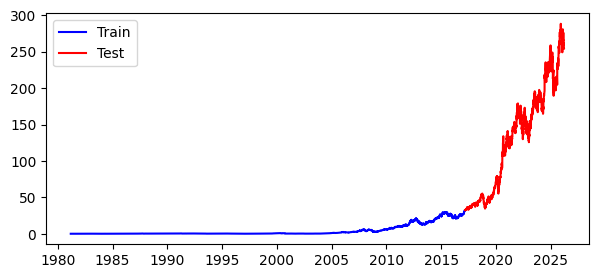

In [17]:
plt.figure(figsize=(7,3))
# y_train and y_test are now 1D arrays
plt.plot( dates_train, y_train, 'b', label='Train' );
plt.plot( dates_test, y_test, 'r', label='Test' );
plt.legend()

In [18]:
'''# Simple index-based split
split_idx = int(len(X) * 0.9)
X_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]
X_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test:  X={X_test.shape}, y={y_test.shape}")'''

'# Simple index-based split\nsplit_idx = int(len(X) * 0.9)\nX_train, y_train, dates_train = X[:split_idx], y[:split_idx], dates[:split_idx]\nX_test, y_test, dates_test = X[split_idx:], y[split_idx:], dates[split_idx:]\n\n# Reshape X_train and X_test to be 2D for scikit-learn models\nX_train = X_train.reshape(X_train.shape[0], -1)\nX_test = X_test.reshape(X_test.shape[0], -1)\n\nprint(f"Train: X={X_train.shape}, y={y_train.shape}")\nprint(f"Test:  X={X_test.shape}, y={y_test.shape}")'

# Cross Validation

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = [
    LinearRegression(),
    KNeighborsRegressor(n_neighbors=4, weights='uniform'),
    RandomForestRegressor(n_estimators=10, max_depth=5),
    RandomForestRegressor(n_estimators=30, max_depth=10),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=2),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3),
    GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5),
]

In [20]:
from sklearn.model_selection import cross_val_score, KFold, TimeSeriesSplit

#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Reshape X to be 2-dimensional for scikit-learn models
X_2d = X.reshape(X.shape[0], -1)

for m in models:
    print(m)

    cv_scores = -cross_val_score(m, X_2d, y, cv=kf, scoring='neg_mean_absolute_percentage_error')
    cv_scores = pd.DataFrame(cv_scores)
    display(cv_scores.describe().T)

    print()
# end

LinearRegression()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.013172,0.004354,0.008162,0.010175,0.013509,0.014532,0.01948



KNeighborsRegressor(n_neighbors=4)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.681119,0.222503,0.41377,0.477388,0.771587,0.824351,0.918497



RandomForestRegressor(max_depth=5, n_estimators=10)


...

,count,mean,std,min,25%,50%,75%,max
0,5.0,0.325426,0.253619,0.028374,0.071131,0.4659,0.519843,0.541883



GradientBoostingRegressor()


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.325741,0.254131,0.030155,0.068743,0.4662,0.520411,0.543194



GradientBoostingRegressor(max_depth=5)


,count,mean,std,min,25%,50%,75%,max
0,5.0,0.327634,0.255773,0.029417,0.069765,0.468051,0.527057,0.54388


# Grid SearchCV

In [21]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define models and their parameter grids
param_grids = {
    "KNeighborsRegressor": (
        KNeighborsRegressor(),
        {
            "n_neighbors": [1, 5, 10, 20, 50],
            "weights": ["uniform", "distance"]
        }
    ),

    "RandomForestRegressor": (
        RandomForestRegressor(),
        {
            "n_estimators": [10, 50, 100],
            "max_depth": [3, 5, 10],
            "min_samples_split": [2, 5, 10],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    ),

    "GradientBoostingRegressor": (
        GradientBoostingRegressor(),
        {
            "n_estimators": [50, 100, 200],
            "learning_rate": [0.01, 0.1, 0.2],
            "max_depth": [2, 3, 5],
            'min_samples_leaf': [1, 2, 5, 10]
        }
    )
}

# Define cross-validation strategy
#kf = KFold(n_splits=5, shuffle=True)
kf = TimeSeriesSplit(n_splits=5)

# Store results
results = []

# Perform GridSearchCV for each model
for name, (model, param_grid) in param_grids.items():
    print(f"Performing GridSearchCV for {name}...")

    grid_search = GridSearchCV(model, param_grid, cv=kf, scoring="neg_mean_absolute_percentage_error", n_jobs=-1)
    grid_search.fit(X_2d, y)

    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    results.append({"Model": name, "Best Score": best_score, "Best Params": best_params})
# end

results

Performing GridSearchCV for KNeighborsRegressor...
Performing GridSearchCV for RandomForestRegressor...
Performing GridSearchCV for GradientBoostingRegressor...


[{'Model': 'KNeighborsRegressor',
  'Best Score': np.float64(-0.6663154674458628),
  'Best Params': {'n_neighbors': 50, 'weights': 'uniform'}},
 {'Model': 'RandomForestRegressor',
  'Best Score': np.float64(-0.3261741152024262),
  'Best Params': {'max_depth': 10,
   'min_samples_leaf': 2,
   'min_samples_split': 5,
   'n_estimators': 50}},
 {'Model': 'GradientBoostingRegressor',
  'Best Score': np.float64(-0.32395526368271166),
  'Best Params': {'learning_rate': 0.2,
   'max_depth': 2,
   'min_samples_leaf': 1,
   'n_estimators': 200}}]

# Feature Importance










In [22]:
# Fit a Random Forest model
rf = RandomForestRegressor(n_estimators=1000)
rf.fit(X_2d, y)

# Generate feature names for X_2d
original_features = stocks.columns.tolist()
feature_names_for_X_2d = []
for lag in range(window_size, 0, -1): # Lags from window_size down to 1
    for col in original_features:
        feature_names_for_X_2d.append(f'{col}_lag{lag}')

# Get feature importances
importances = pd.Series(rf.feature_importances_, index=feature_names_for_X_2d).sort_values(ascending=False)
importances = importances[:20]

# Get the names of the selected features
features_rf = importances.index.tolist()

# Create a DataFrame from X_2d with the correct column names for easier slicing
X_2d_df = pd.DataFrame(X_2d, columns=feature_names_for_X_2d)

# Select only the important features from X_2d_df
X_pars = X_2d_df[features_rf]

importances

,0
Close_lag1,0.511056
Low_lag1,0.210184
High_lag1,0.100652
Close_lag2,0.043445
Low_lag2,0.028240
Open_lag1,0.021976
High_lag2,0.015892
Open_lag2,0.015091
Close_lag3,0.014159
Low_lag3,0.010572


# KERAS

In [29]:
!pip install tensorflow

In [30]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=X_train.shape[1]),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='relu'),
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

In [31]:
from sklearn.model_selection import KFold, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Re-defining build_model with the fix for the Input layer
from keras.models import Sequential
from keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_model( X_train, epochs, batch_size, decay_frac, initial_learning_rate, dropout_rate ):

    # Create model
    model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])), # Corrected: Input layer now expects 3D shape
        Flatten(), # Added: Flatten the input for Dense layers
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dropout(dropout_rate),
        Dense(20, activation='relu'),
        Dense(1, activation='linear'), # Changed activation to 'linear' for regression
    ])

    # define training parameters
    decay_epochs    = int( epochs * decay_frac )
    n_train         = X_train.shape[0]
    steps_per_epoch = int( np.ceil( n_train / batch_size ) )
    decay_steps     = decay_epochs * steps_per_epoch

    lr_schedule_poly = PolynomialDecay(
        initial_learning_rate=initial_learning_rate,
        end_learning_rate=0.001,
        decay_steps=decay_steps,
        power=2.0
    )

    # Define the optimizer with a custom learning rate
    optimizer = Adam(
        learning_rate=lr_schedule_poly,
    )

    # Compile model
    model.compile(
        optimizer=optimizer,
        loss='mae'
    )

    return model
# end

epochs                = 500
batch_size            = 256
decay_frac            = 0.8
dropout_rate          = 0.25
initial_learning_rate = 0.01

n_splits = 5
#kf = KFold(n_splits=n_splits, shuffle=True)
kf = TimeSeriesSplit(n_splits=n_splits)

train_mae_list = []
test_mae_list = []
train_r2_list = []
test_r2_list = []

fold = 1
for train_index, test_index in kf.split(X):
    print(f"Fold {fold}/{n_splits}")
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y[train_index], y[test_index]

    # Scale X_train_fold and y_train_fold for the neural network
    # Flatten X_train_fold and X_test_fold for scaling, then reshape back
    scaler_X = MinMaxScaler(feature_range=(0,1))
    X_train_flat = X_train_fold.reshape(X_train_fold.shape[0], -1)
    X_test_flat = X_test_fold.reshape(X_test_fold.shape[0], -1)

    X_train_scaled = scaler_X.fit_transform(X_train_flat)
    X_test_scaled = scaler_X.transform(X_test_flat)

    X_train_scaled = X_train_scaled.reshape(X_train_fold.shape)
    X_test_scaled = X_test_scaled.reshape(X_test_fold.shape)

    scaler_y = MinMaxScaler(feature_range=(0,1))
    y_train_scaled = scaler_y.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y.transform(y_test_fold.reshape(-1, 1))

    # Build a fresh model (which resets optimizer state including the learning rate schedule)
    model = build_model(
        X_train_scaled,
        epochs,
        batch_size,
        decay_frac,
        initial_learning_rate,
        dropout_rate
    )

    # Early stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',  # Monitor validation loss
        patience=100,          # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights after stopping
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping]
    )

    # Evaluate on training data
    y_train_pred_scaled = model.predict(X_train_scaled, verbose=0)
    y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled) # Inverse transform predictions
    train_mae = mean_absolute_error(y_train_fold, y_train_pred)
    train_r2 = r2_score(y_train_fold, y_train_pred)

    # Evaluate on test data
    y_test_pred_scaled = model.predict(X_test_scaled, verbose=0)
    y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled) # Inverse transform predictions
    test_mae = mean_absolute_error(y_test_fold, y_test_pred)
    test_r2 = r2_score(y_test_fold, y_test_pred)

    print("MAE:")
    print(f"  Train: {train_mae:.4f}")
    print(f"  Test:  {test_mae:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2:.4f}")
    print(f"  Test:  {test_r2:.4f}")
    print()

    train_mae_list.append(train_mae)
    test_mae_list.append(test_mae)
    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    fold += 1
# end

Fold 1/5
MAE:
  Train: 0.0266
  Test:  0.0620
R^2:
  Train: 0.8271
  Test:  0.0568

Fold 2/5
MAE:
  Train: 0.0565
  Test:  0.0883
R^2:
  Train: 0.6514
  Test:  0.7121

Fold 3/5
MAE:
  Train: 0.0557
  Test:  1.2491
R^2:
  Train: 0.7570
  Test:  0.6394

Fold 4/5
MAE:
  Train: 0.4065
  Test:  9.3692
R^2:
  Train: 0.7950
  Test:  -0.0657

Fold 5/5
MAE:
  Train: 2.2524
  Test:  59.0878
R^2:
  Train: 0.7899
  Test:  0.0364



In [32]:
'''from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,
                                                    test_size=0.2, shuffle=False)'''

'from sklearn.model_selection import train_test_split\n\nX_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_pars, y, dates,\n                                                    test_size=0.2, shuffle=False)'

In [33]:
'''results_df = pd.DataFrame({
    'Train MAE': train_mae_list,
    'Test MAE': test_mae_list,
    'Train R2': train_r2_list,
    'Test R2': test_r2_list
})

results_df.describe()'''

"results_df = pd.DataFrame({\n    'Train MAE': train_mae_list,\n    'Test MAE': test_mae_list,\n    'Train R2': train_r2_list,\n    'Test R2': test_r2_list\n})\n\nresults_df.describe()"

# Model Creation

In [35]:
dropout_rate = 0.1

model_dense  = Sequential([
    Input(shape=(X_train_2d.shape[1],)), # Corrected input shape

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(16, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    Dense(8, activation='relu'),

    Dense(1, activation='linear'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.01)

# Compile model
model_dense .compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_dense .summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 32)             │         2,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,041 (11.88 KB)

 Non-trainable params: 96 (384.00 B)

In [36]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_2d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [38]:
history_dense = model_dense.fit(
    X_train_2d, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_2d, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.7947 - val_loss: 130.3886
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7219 - val_loss: 130.3741
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.7093 - val_loss: 130.3295
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6972 - val_loss: 130.3706
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6969 - val_loss: 130.3549
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6857 - val_loss: 130.3481
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6634 - val_loss: 130.3411
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6632 - val_loss: 130.3582
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6519 - val_loss: 130.3947
Epoch 10/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6588 - val_loss: 130.3568
Epoch 11/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.6542 - val_loss: 130.3566
Epoch 12/150
142/14

284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 554us/step
r2_train:   -0.16301
r2_test:    -3.2189
rmse_train: 8.1286
rmse_test:  149.15


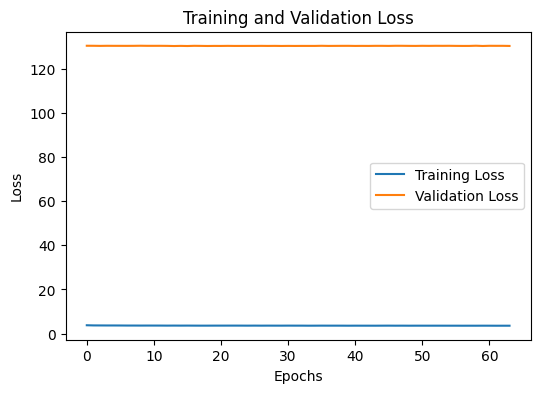

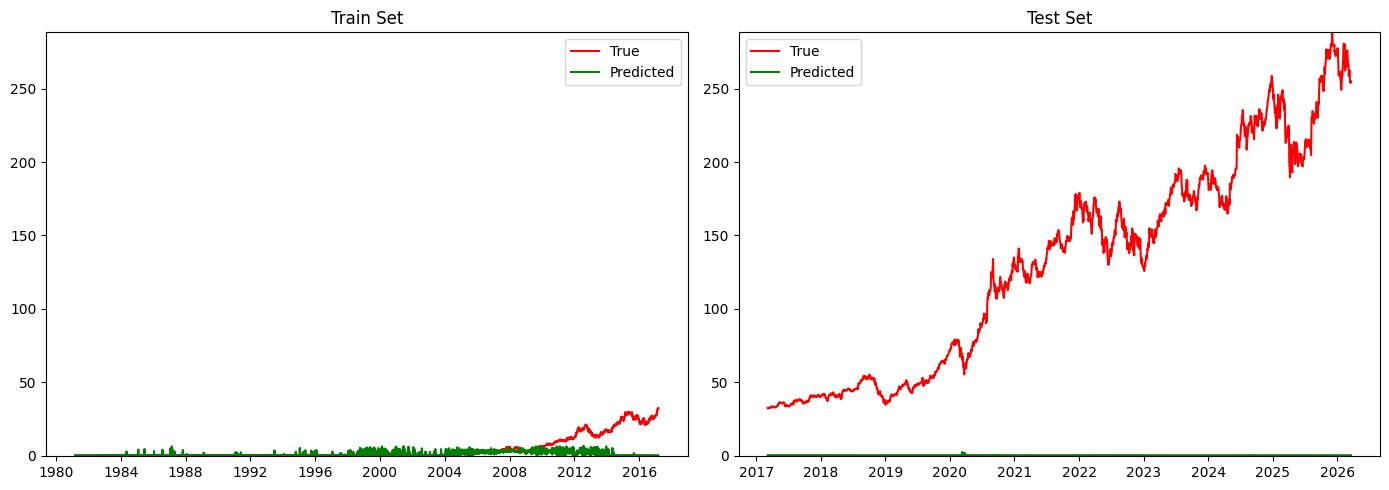

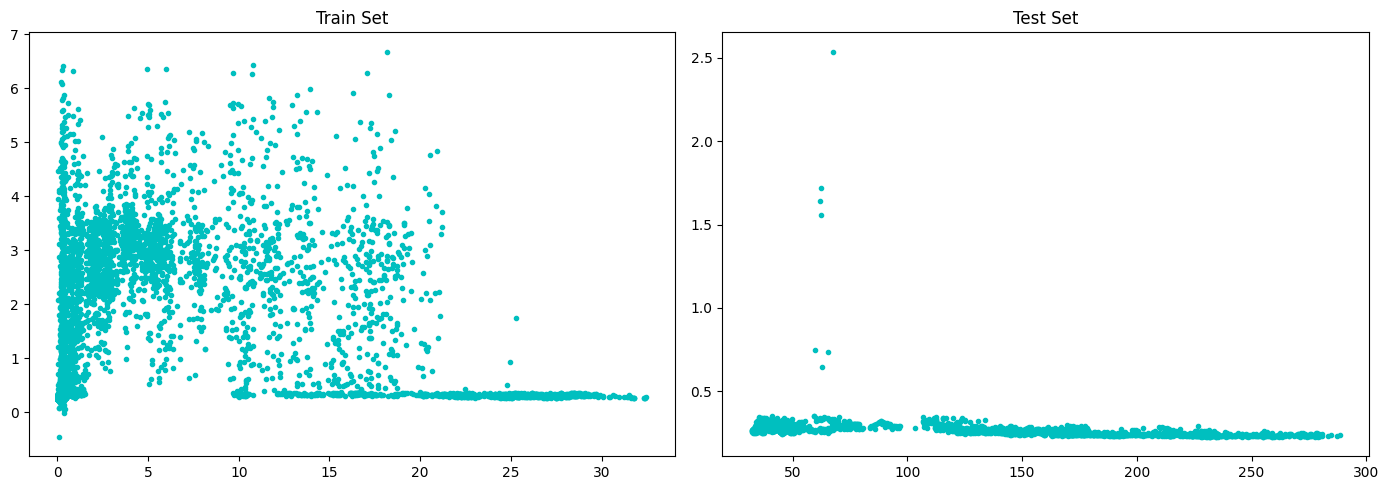

MAE:
  Train: 3.6489
  Test:  130.2677
R^2:
  Train: -0.1630
  Test:  -3.2189


In [39]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Get predictions
y_train_pred = model_dense.predict(X_train_2d)[:,0]
y_test_pred  = model_dense.predict(X_test_2d)[:,0]

# Create a figure with two subplots side by side
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Left subplot: Training and Validation Loss
ax.plot(history_dense.history['loss'], label='Training Loss')
ax.plot(history_dense.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()

r2_train = r2_score(y_train, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

y_train_pred = pd.Series(y_train_pred, index=dates_train)
y_test_pred  = pd.Series(y_test_pred, index=dates_test)

# Calculate global y-axis limits
y_min = min(y_train.min(), y_train_pred.min(), y_test.min(), y_test_pred.min())
y_max = max(y_train.max(), y_train_pred.max(), y_test.max(), y_test_pred.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train, y_train, 'r', label='True')
axs[0].plot(y_train_pred, 'g', label='Predicted')
axs[0].set_title('Train Set')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test, y_test, 'r', label='True')
axs[1].plot(y_test_pred, 'g', label='Predicted')
axs[1].set_title('Test Set')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train, y_train_pred.values, 'c.')
axs[0].set_title('Train Set')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test, y_test_pred.values, 'c.')
axs[1].set_title('Test Set')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

# LSTM

In [40]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay

# define training parameters
epochs          = 500
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.05

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='mae'
)

In [41]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

In [44]:
X_train_2 = X_train_3d # X_train_3d is already in the correct 3D shape (samples, timesteps, features)
X_test_2 = X_test_3d   # X_test_3d is already in the correct 3D shape (samples, timesteps, features)

# Determine the number of features from X_train_3d's last dimension
num_features = X_train_3d.shape[2]

model_lstm = Sequential([
    # The input shape for LSTM layers should be (timesteps, features)
    Input(shape=(window_size, num_features)),

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.001)

# Compile model
model_lstm.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

In [45]:
X_train_3d.shape

(9077, 10, 7)

In [46]:
history_lstm = model_lstm.fit(
    X_train_2, y_train,
    epochs=150,
    batch_size=64,
    validation_data=(X_test_2, y_test),
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 3.9923 - val_loss: 130.2002
Epoch 2/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9785 - val_loss: 130.2487
Epoch 3/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9755 - val_loss: 130.2475
Epoch 4/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9750 - val_loss: 130.2331
Epoch 5/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9738 - val_loss: 130.2557
Epoch 6/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9736 - val_loss: 130.2394
Epoch 7/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9736 - val_loss: 130.2219
Epoch 8/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9730 - val_loss: 130.2143
Epoch 9/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9732 - val_loss: 130.1883
Epoch 10/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9728 - val_loss: 130.1971
Epoch 11/150
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9722 - val_loss: 130.2033
Epoch 12/150
142/14

284/284 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


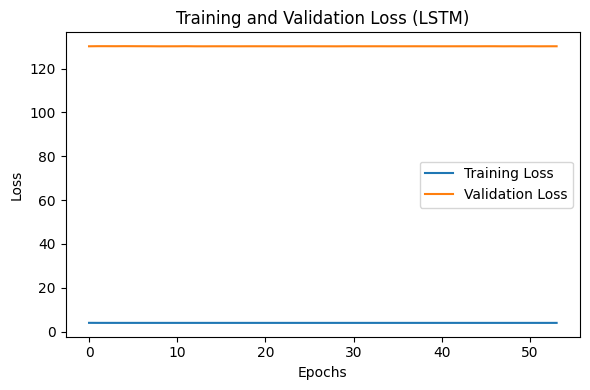

r2_train:   -0.25702
r2_test:    -3.2142
rmse_train: 8.4508
rmse_test:  149.07


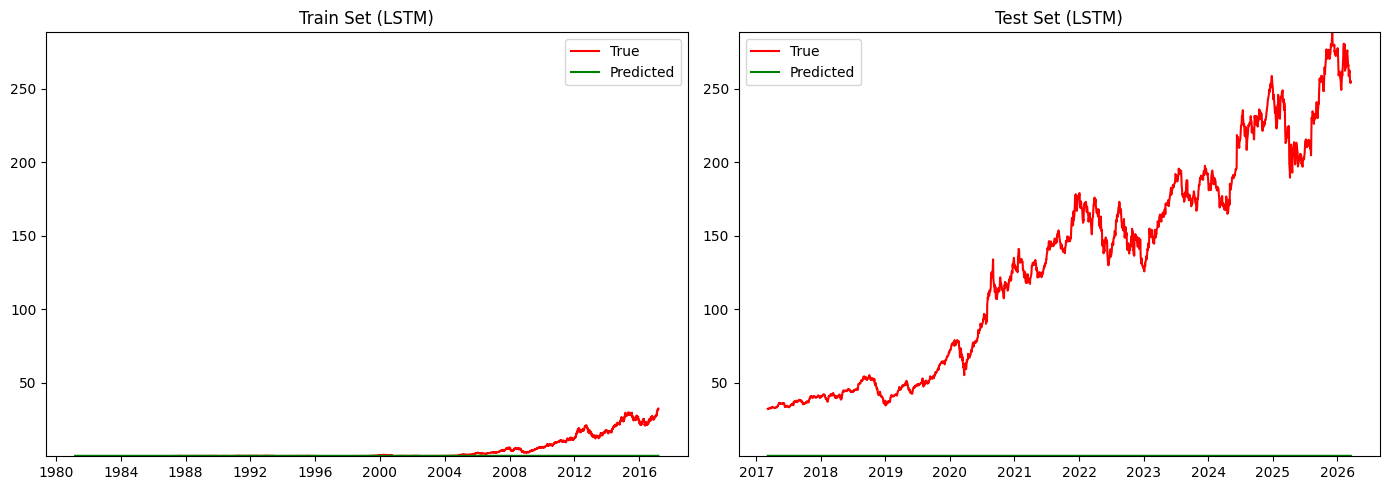

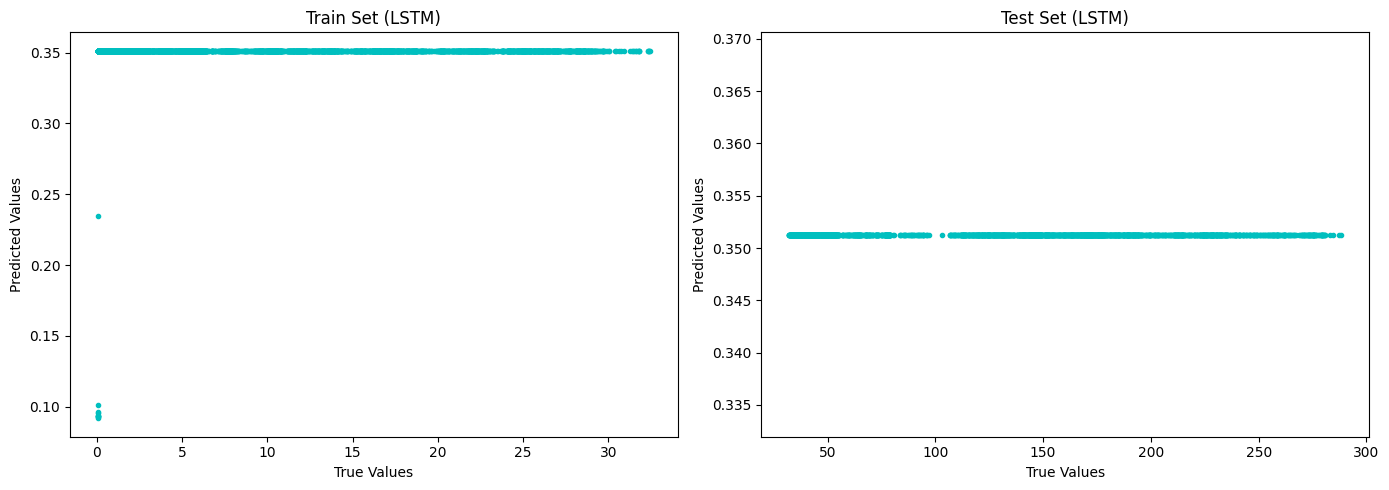

MAE:
  Train: 3.9723
  Test:  130.1843
R^2:
  Train: -0.2570
  Test:  -3.2142


In [47]:
# Get predictions
# Use the already reshaped X_train_2 and X_test_2 for LSTM predictions.
y_train_pred = model_lstm.predict(X_train_2)[:,0]
y_test_pred  = model_lstm.predict(X_test_2)[:,0]

# Now use the true values and dates from the train_test_split
y_train_true = y_train
y_test_true = y_test
dates_train_plot = dates_train
dates_test_plot = dates_test

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm.history['loss'], label='Training Loss')
ax.plot(history_lstm.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred, index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred, index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

In [48]:
# Create a DataFrame to organize the data of true vs pred data graph
predicted_results_df_corrected = pd.DataFrame({
    'Actual Close Price': pd.Series(y_test_true, index=dates_test_plot), # Use y_test_true and dates_test_plot
    'Predicted Stock Price': pd.Series(y_test_pred, index=dates_test_plot),
    'Difference (Error)': (pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot)),
    'Percentage Error (%)': ((abs(pd.Series(y_test_true, index=dates_test_plot) - pd.Series(y_test_pred, index=dates_test_plot))) / pd.Series(y_test_true, index=dates_test_plot)) * 100
})

# Get the original 'Open' prices from the stocks DataFrame using dates_test_plot's index
# Note: 'stocks' DataFrame has 'Open' (capital O) column
open_prices = stocks.loc[dates_test_plot, ['Open']]

# Merge this information into predicted_results_df, aligning by index
predicted_results_df_corrected = predicted_results_df_corrected.merge(open_prices, left_index=True, right_index=True)

# Reorder columns for clarity, putting 'Open' and 'Actual Close Price' first
predicted_results_df_corrected = predicted_results_df_corrected[[
    'Open', 'Actual Close Price', 'Predicted Stock Price',
    'Difference (Error)', 'Percentage Error (%)'
]]

# Sort the DataFrame by its index (dates) to enable proper time-series slicing
predicted_results_df_corrected = predicted_results_df_corrected.sort_index()

# Display the corrected numerical table filtered from 2007 to 2026
display(predicted_results_df_corrected.loc['2025':'2026'])

,Open,Actual Close Price,Predicted Stock Price,Difference (Error),Percentage Error (%)
2025-01-02,247.577549,247.746638,0.351288,247.395350,99.858207
2025-01-03,242.037811,242.853348,0.351288,242.502060,99.855350
2025-01-06,242.982661,245.986258,0.351288,245.634970,99.857192
2025-01-07,241.659879,244.215924,0.351288,243.864636,99.856157
2025-01-08,240.605648,242.385931,0.351288,242.034643,99.855071
...,...,...,...,...,...
2026-03-12,258.660004,258.950012,0.351288,258.598724,99.864341
2026-03-13,255.479996,256.329987,0.351288,255.978699,99.862955
2026-03-16,252.110001,253.889999,0.351288,253.538711,99.861638
2026-03-17,252.960007,255.130005,0.351288,254.778717,99.862310


###Gemini Suggestion and my fix

### Scaling Data for LSTM Training

The previous LSTM model was trained on unscaled data. It's crucial for neural networks like LSTMs to train on scaled data for better convergence and performance. We will now apply `MinMaxScaler` to the training and testing sets of `X` and `y` that were derived from the feature-selected data (`X_pars`).

The `scaler_X_final` will be fitted on the 2D `X_train` (before reshaping to 3D for LSTM) and `scaler_y_final` will be fitted on `y_train`. These scalers will then be used to transform both the training and testing sets.

In [49]:
recent_stocks = stocks.tail(574)
recent_stocks

,Open,High,Low,Close,Volume,Moving_Average,RSI
Date,,,,,,,
2023-12-01,188.373065,189.590414,187.284369,189.273712,45704800,177.446822,67.053646
2023-12-04,188.026663,188.095951,185.522677,187.482315,43389500,177.741163,61.115171
2023-12-05,188.254333,192.401240,188.224627,191.431320,66628400,178.088983,67.841875
2023-12-06,192.450710,192.757521,190.134773,190.342621,41089700,178.496475,64.543803
2023-12-07,191.639164,192.995073,191.599567,192.272583,47477700,178.972812,67.540913
...,...,...,...,...,...,...,...
2026-03-12,258.660004,258.950012,254.179993,255.759995,40794000,263.034650,40.400334
2026-03-13,255.479996,256.329987,249.520004,250.119995,36930000,262.580556,35.468931
2026-03-16,252.110001,253.889999,249.880005,252.820007,32074200,262.204839,39.271095


### If it doesnt work run lstm in new notebook

In [50]:
# Create lagged sequences
window_size = 10

#perm = np.arange(window_size)
perm = np.random.permutation(np.arange(window_size))

X_recent, y_recent = [], []
dates_recent = []
for i in range(len(recent_stocks) - window_size):
    X_recent.append(recent_stocks.iloc[i:i+window_size].values)
    # Predict only the 'close' price (index 1) for y
    y_recent.append(recent_stocks.iloc[i+window_size, 1])
    dates_recent.append(recent_stocks.index[i+window_size])

X_recent = np.array(X_recent)
y_recent = np.array(y_recent)
dates_recent = np.array(dates_recent)

print(f"X shape: {X_recent.shape}, y shape: {y_recent.shape}")

X shape: (564, 10, 7), y shape: (564,)


In [ ]:
'''# Simple index-based split
split_idx = int(len(X_recent) * 0.9)
X_train_recent, y_train_recent, dates_recent_train = X_recent[:split_idx], y_recent[:split_idx], dates_recent[:split_idx]
X_test_recent, y_test_recent, dates_test_recent = X_recent[split_idx:], y_recent[split_idx:], dates_recent[split_idx:]

# Reshape X_train and X_test to be 2D for scikit-learn models
X_train_recent = X_train_recent.reshape(X_train_recent.shape[0], -1)
X_test_recent = X_test_recent.reshape(X_test_recent.shape[0], -1)

print(f"Train: X={X_train_recent.shape}, y={y_train_recent.shape}")
print(f"Test:  X={X_test_recent.shape}, y={y_test_recent.shape}")'''

In [ ]:
'''from sklearn.preprocessing import MinMaxScaler
import joblib # For saving/loading scalers

# Initialize scalers
scaler_X_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final = MinMaxScaler(feature_range=(0, 1))

# Fit and transform X_train and X_test
# Note: X_train and X_test are currently 2D from FTH25CdEe2Sm
X_train_scaled_2d = scaler_X_final.fit_transform(X_train_recent)
X_test_scaled_2d = scaler_X_final.transform(X_test_recent)

# Fit and transform y_train and y_test
y_train_scaled = scaler_y_final.fit_transform(y_train_recent.reshape(-1, 1))
y_test_scaled = scaler_y_final.transform(y_test_recent.reshape(-1, 1))

print("Data scaled successfully.")

# Reshape the scaled X data into 3D for LSTM input
window_size = 10 # This should be consistent with how X was created in DrO4kslNboUk
num_features = X_train_scaled_2d.shape[1] // window_size # Number of original features

X_train_scaled_3d = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], window_size, num_features))
X_test_scaled_3d = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], window_size, num_features))

print(f"Reshaped X_train_scaled_3d shape: {X_train_scaled_3d.shape}")
print(f"Reshaped X_test_scaled_3d shape: {X_test_scaled_3d.shape}")'''

### Time Series Cross-Validation for LSTM Model

This provide a more robust evaluation of the model's performance across different time periods, similar to how other models were evaluated.

In [51]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np

# Define the LSTM model building function for cross-validation
def build_lstm_model_cv(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Assuming X_recent and y_recent are already defined and represent the data to be used
# X_recent has shape (n_samples, window_size, n_features)
# y_recent has shape (n_samples,)

# Define cross-validation parameters
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

epochs = 150 # adjust this
batch_size = 64 # adjust this

train_mae_cv_list = []
test_mae_cv_list = []
train_r2_cv_list = []
test_r2_cv_list = []

fold = 1
# X_recent and y_recent are 3D and 1D respectively, but TimeSeriesSplit expects 2D array for X
# We will use X_recent_2d and reshape within the loop for LSTM input

# First, reshape X_recent to 2D for TimeSeriesSplit
X_recent_2d = X_recent.reshape(X_recent.shape[0], -1)

for train_index, test_index in kf_time_series.split(X_recent_2d):
    print(f"Fold {fold}/{n_splits}")

    # Split data for the current fold
    X_train_fold_2d, X_test_fold_2d = X_recent_2d[train_index], X_recent_2d[test_index]
    y_train_fold, y_test_fold = y_recent[train_index], y_recent[test_index]

    # Scale X and y within the fold to prevent data leakage
    scaler_X_cv = MinMaxScaler(feature_range=(0, 1))
    scaler_y_cv = MinMaxScaler(feature_range=(0, 1))

    X_train_scaled_2d = scaler_X_cv.fit_transform(X_train_fold_2d)
    X_test_scaled_2d = scaler_X_cv.transform(X_test_fold_2d)

    y_train_scaled = scaler_y_cv.fit_transform(y_train_fold.reshape(-1, 1))
    y_test_scaled = scaler_y_cv.transform(y_test_fold.reshape(-1, 1))

    # Reshape scaled X data to 3D for LSTM input
    current_window_size = X_recent.shape[1] # This should be 10
    current_num_features = X_recent.shape[2] # This should be 5

    X_train_scaled_3d_cv = X_train_scaled_2d.reshape((X_train_scaled_2d.shape[0], current_window_size, current_num_features))
    X_test_scaled_3d_cv = X_test_scaled_2d.reshape((X_test_scaled_2d.shape[0], current_window_size, current_num_features))

    # Build a fresh LSTM model for each fold
    model_lstm_cv = build_lstm_model_cv(current_window_size, current_num_features)

    # Early stopping callback
    early_stopping_cv = EarlyStopping(
        monitor='val_loss',
        patience=25, # Adjusted patience for cross-validation
        restore_best_weights=True
    )

    # Train the model
    history_cv = model_lstm_cv.fit(
        X_train_scaled_3d_cv, y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test_scaled_3d_cv, y_test_scaled),
        verbose=0,
        callbacks=[early_stopping_cv]
    )

    # Evaluate on training data
    y_train_pred_scaled_cv = model_lstm_cv.predict(X_train_scaled_3d_cv, verbose=0)
    y_train_pred_cv = scaler_y_cv.inverse_transform(y_train_pred_scaled_cv) # Inverse transform predictions
    train_mae_cv = mean_absolute_error(y_train_fold, y_train_pred_cv)
    train_r2_cv = r2_score(y_train_fold, y_train_pred_cv)

    # Evaluate on test data
    y_test_pred_scaled_cv = model_lstm_cv.predict(X_test_scaled_3d_cv, verbose=0)
    y_test_pred_cv = scaler_y_cv.inverse_transform(y_test_pred_scaled_cv) # Inverse transform predictions
    test_mae_cv = mean_absolute_error(y_test_fold, y_test_pred_cv)
    test_r2_cv = r2_score(y_test_fold, y_test_pred_cv)

    print("MAE:")
    print(f"  Train: {train_mae_cv:.4f}")
    print(f"  Test:  {test_mae_cv:.4f}")
    print("R^2:")
    print(f"  Train: {train_r2_cv:.4f}")
    print(f"  Test:  {test_r2_cv:.4f}")
    print()

    train_mae_cv_list.append(train_mae_cv)
    test_mae_cv_list.append(test_mae_cv)
    train_r2_cv_list.append(train_r2_cv)
    test_r2_cv_list.append(test_r2_cv)

    fold += 1
# end

print("\nCross-validation results:")
cv_results_df = pd.DataFrame({
    'Train MAE': train_mae_cv_list,
    'Test MAE': test_mae_cv_list,
    'Train R2': train_r2_cv_list,
    'Test R2': test_r2_cv_list
})
display(cv_results_df)
display(cv_results_df.describe())

Fold 1/5
MAE:
  Train: 2.7231
  Test:  21.4975
R^2:
  Train: 0.8560
  Test:  -1.1677

Fold 2/5
MAE:
  Train: 5.7362
  Test:  13.5598
R^2:
  Train: 0.8804
  Test:  -1.5394

Fold 3/5
MAE:
  Train: 4.5027
  Test:  5.4181
R^2:
  Train: 0.9548
  Test:  0.8049

Fold 4/5
MAE:
  Train: 3.3105
  Test:  6.7782
R^2:
  Train: 0.9664
  Test:  0.8184

Fold 5/5
MAE:
  Train: 4.4862
  Test:  2.8144
R^2:
  Train: 0.9495
  Test:  0.8104


Cross-validation results:


,Train MAE,Test MAE,Train R2,Test R2
0,2.723117,21.497483,0.855968,-1.167720
1,5.736243,13.559844,0.880354,-1.539420
2,4.502732,5.418059,0.954797,0.804858
3,3.310472,6.778190,0.966437,0.818434
4,4.486230,2.814382,0.949472,0.810367


,Train MAE,Test MAE,Train R2,Test R2
count,5.000000,5.000000,5.000000,5.000000
mean,4.151759,10.013592,0.921406,-0.054696
std,1.172009,7.547699,0.049744,1.192974
min,2.723117,2.814382,0.855968,-1.539420
25%,3.310472,5.418059,0.880354,-1.167720
50%,4.486230,6.778190,0.949472,0.804858
75%,4.502732,13.559844,0.954797,0.810367
max,5.736243,21.497483,0.966437,0.818434


In [ ]:
#X_train_scaled_3d_cv.shape

In [ ]:
#y_train_pred_cv.shape

In [ ]:
#X_train_scaled_3d.shape

In [ ]:
#y_train_pred.shape

In [ ]:
#y_train_recent.shape

In [ ]:
'''from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(X_recent, y_recent, dates_recent,
                                                    test_size=0.2, random_state=42)'''

In [52]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay, PolynomialDecay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input

# define training parameters
epochs          = 250
batch_size      = 256
decay_epochs    = int( epochs * 0.5 )

n_train         = X_train_3d.shape[0]
steps_per_epoch = int( np.ceil( n_train / batch_size ) )
decay_steps     = decay_epochs * steps_per_epoch
#print(decay_steps)

# Define the learning rate schedule
initial_learning_rate = 0.001 # Changed from 0.05 to 0.001 to match CV setup

lr_schedule_exp = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_rate=5.0,
    decay_steps=decay_steps
)

lr_schedule_poly = PolynomialDecay(
    initial_learning_rate=initial_learning_rate,
    end_learning_rate=0.001,
    decay_steps=decay_steps,
    power=1.0
)

# Define model_lstm_final (moved from a later cell)
window_size = 10 # Assuming this is consistent
num_features = X_train_3d.shape[1] // window_size # Derive num_features from X_train_recent which is a 2D array

model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer with a custom learning rate
optimizer = Adam(
    learning_rate=initial_learning_rate,
    #learning_rate=lr_schedule_exp,
    #learning_rate=lr_schedule_poly,
    #clipnorm=1,
    #clipvalue=1,
)

# Compile model
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae'
)

In [53]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=50,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Callback to reduce LR when a monitored metric has stopped improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',       # metric to monitor
    factor=0.5,               # factor by which to reduce the LR
    patience=50,              # number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,              # lower bound on the learning rate
    verbose=1                 # print when LR is reduced
)

### Retraining LSTM Model with Scaled Data

Now we will define and retrain the LSTM model using the newly scaled `X_train_scaled_3d` and `y_train_scaled` data. We will use the same architecture and early stopping mechanism as before. After training, we will evaluate its performance.

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import MinMaxScaler # Import MinMaxScaler

# Correctly determine the number of features from the scaled 3D data
num_features = X_train_scaled_3d_cv.shape[2]

# Define the LSTM model with the same architecture as before
model_lstm_final = Sequential([
    Input(shape=(window_size, num_features)), # Use the correctly calculated num_features

    LSTM(64, return_sequences=True),
    Dropout(0.2),
    BatchNormalization(),

    LSTM(32, return_sequences=False),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(1)
])

# Define the optimizer and compile the model
optimizer = Adam(learning_rate=0.001) # Use the same learning rate as previous LSTM
model_lstm_final.compile(
    optimizer=optimizer,
    loss='mae',
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=25,          # Stop after 25 epochs without improvement (consistent with previous)
    restore_best_weights=True  # Restore the best weights after stopping
)

model_lstm_final.summary()

# --- Start of added check for data cardinality ---
#print(f"Checking X_train_scaled_3d shape: {X_train_scaled_3d_cv.shape}")
#print(f"Checking y_train_scaled shape: {y_train_scaled.shape}")

#if X_train_scaled_3d.shape[0] != y_train_scaled.shape[0]:
#    raise ValueError(f"Data cardinality mismatch: X_train has {X_train_scaled_3d.shape[0]} samples, but y_train has {y_train_scaled.shape[0]} samples.")
# --- End of added check for data cardinality ---

# Initialize and fit scaler_y_final with the unscaled y_train_fold from the last CV fold
scaler_y_final = MinMaxScaler(feature_range=(0, 1))
scaler_y_final.fit(y_train_fold.reshape(-1, 1))

# Train the model with scaled data
history_lstm_final = model_lstm_final.fit(
    X_train_scaled_3d_cv, y_train_scaled,
    epochs=250, # Use same number of epochs
    batch_size=64, # Reverting batch size as per user's preference
    validation_data=(X_test_scaled_3d_cv, y_test_scaled),
    verbose=1,
    callbacks=[early_stopping]
)

# Get predictions using the final model
y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale
y_train_pred = scaler_y_final.inverse_transform(y_train_pred_scaled)
y_test_pred  = scaler_y_final.inverse_transform(y_test_pred_scaled)

# Inverse transform true values for consistent comparison based on the cv fold
y_train_true_original = y_train_fold
y_test_true_original = y_test_fold

# Calculate metrics for the retrained LSTM model
r2_train = r2_score(y_train_true_original, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true_original, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true_original, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true_original, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_16 (LSTM)                  │ (None, 10, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 10, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,193 (125.75 KB)

 Trainable params: 32,065 (125.25 KB)

 Non-trainable params: 128 (512.00 B)

Epoch 1/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.3514 - val_loss: 0.4861
Epoch 2/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1974 - val_loss: 0.5528
Epoch 3/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1705 - val_loss: 0.5015
Epoch 4/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1415 - val_loss: 0.4484
Epoch 5/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1195 - val_loss: 0.4794
Epoch 6/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1164 - val_loss: 0.4357
Epoch 7/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1104 - val_loss: 0.4677
Epoch 8/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1007 - val_loss: 0.4447
Epoch 9/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0954 - val_loss: 0.4288
Epoch 10/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0917 - val_loss: 0.4278
Epoch 11/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0897 - val_loss: 0.3939
Epoch 12/250
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0824 - val_lo

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


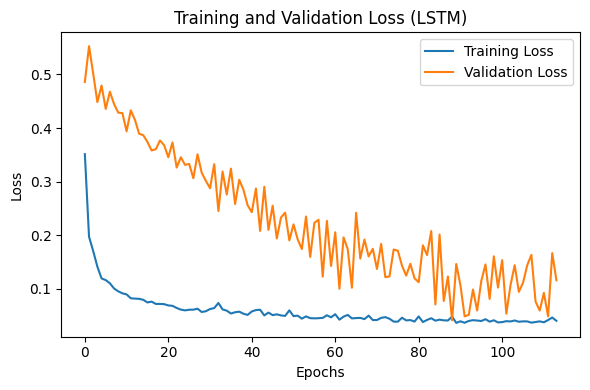

r2_train:   0.96551
r2_test:    0.6352
rmse_train: 4.6086
rmse_test:  5.345


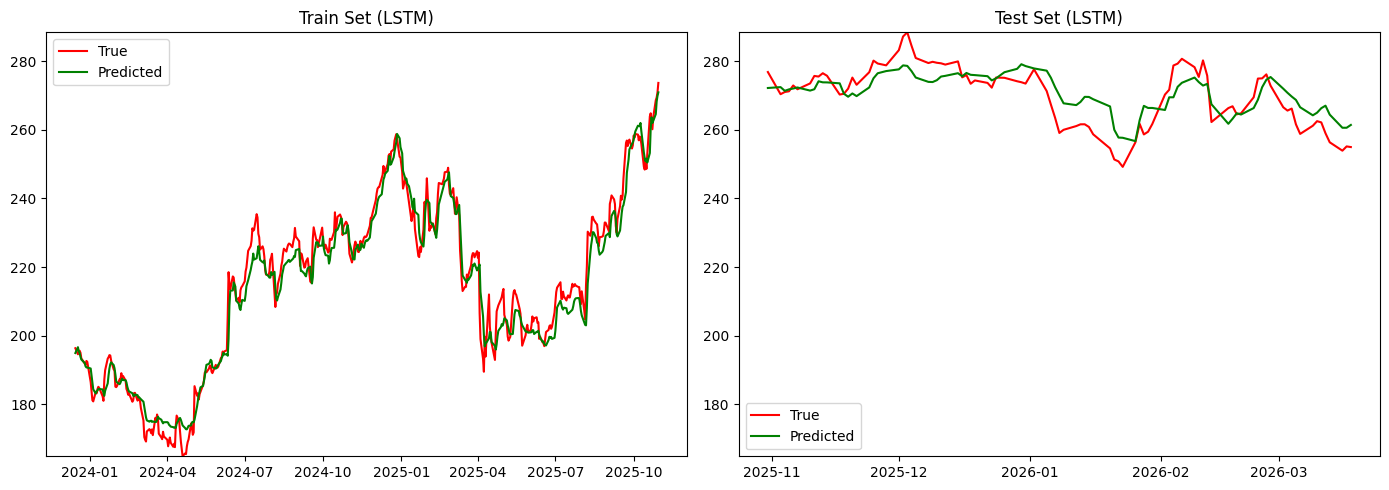

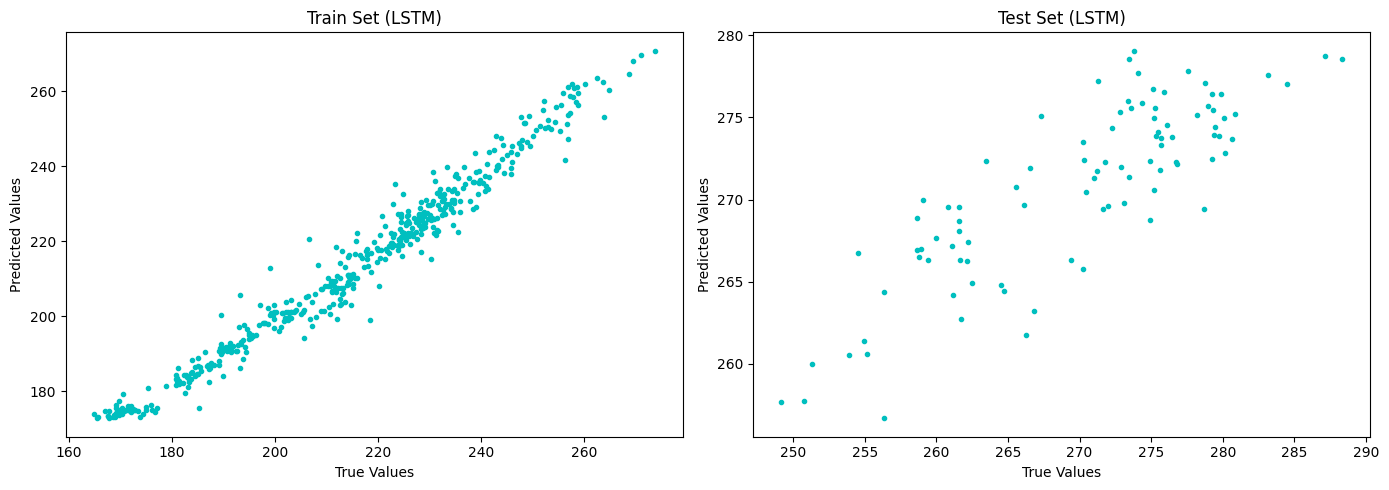

MAE:
  Train: 3.5747
  Test:  4.5035
R^2:
  Train: 0.9655
  Test:  0.6352


In [56]:
n_splits = 5 # Assuming n_splits is 5 as used in previous CV
kf_time_series_reget = TimeSeriesSplit(n_splits=n_splits)

last_train_index = None
last_test_index = None
last_y_train_fold = None
last_y_test_fold = None
last_scaler_y_cv = None

# Iterate through the splits to get the data and scaler for the last fold
# X_recent_2d is assumed to be available from prior cells.
for i, (tr_idx, ts_idx) in enumerate(kf_time_series_reget.split(X_recent_2d)):
    if i == n_splits - 1: # This is the last fold
        last_train_index = tr_idx
        last_test_index = ts_idx
        last_y_train_fold = y_recent[tr_idx]
        last_y_test_fold = y_recent[ts_idx]

        # Recreate scaler_y_cv for the last fold to ensure consistency
        temp_scaler_y_cv = MinMaxScaler(feature_range=(0,1))
        temp_scaler_y_cv.fit(last_y_train_fold.reshape(-1, 1))
        last_scaler_y_cv = temp_scaler_y_cv
        break


y_train_pred_scaled = model_lstm_final.predict(X_train_scaled_3d_cv)
y_test_pred_scaled  = model_lstm_final.predict(X_test_scaled_3d_cv)

# Inverse transform predictions to original scale using the correct scaler_y_cv
y_train_pred = last_scaler_y_cv.inverse_transform(y_train_pred_scaled)
y_test_pred  = last_scaler_y_cv.inverse_transform(y_test_pred_scaled)

# Now use the true values and dates from the last fold's split
y_train_true = last_y_train_fold.reshape(-1, 1)
y_test_true = last_y_test_fold.reshape(-1, 1)
dates_train_plot = dates_recent[last_train_index]
dates_test_plot = dates_recent[last_test_index]

# Create a figure with one subplot for loss
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot Training and Validation Loss
ax.plot(history_lstm_final.history['loss'], label='Training Loss')
ax.plot(history_lstm_final.history['val_loss'], label='Validation Loss')
ax.set_title('Training and Validation Loss (LSTM)')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for LSTM model
r2_train = r2_score(y_train_true, y_train_pred)
print(f'r2_train:   {r2_train:.5}')

r2_test = r2_score(y_test_true, y_test_pred)
print(f'r2_test:    {r2_test:.5}')

rmse_train = mean_squared_error(y_train_true, y_train_pred)**0.5
print(f'rmse_train: {rmse_train:.5}')

rmse_test = mean_squared_error(y_test_true, y_test_pred)**0.5
print(f'rmse_test:  {rmse_test:.5}')

# Convert predictions to pandas Series with dates as index for plotting
y_train_pred_series = pd.Series(y_train_pred.flatten(), index=dates_train_plot)
y_test_pred_series  = pd.Series(y_test_pred.flatten(), index=dates_test_plot)

# Calculate global y-axis limits for consistent plotting
y_min = min(y_train_true.min(), y_train_pred_series.min(), y_test_true.min(), y_test_pred_series.min())
y_max = max(y_train_true.max(), y_train_pred_series.max(), y_test_true.max(), y_test_pred_series.max())

# Plot train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_plot, y_train_true, 'r', label='True')
axs[0].plot(y_train_pred_series, 'g', label='Predicted')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_ylim(y_min, y_max)
axs[0].legend()

axs[1].plot(dates_test_plot, y_test_true, 'r', label='True')
axs[1].plot(y_test_pred_series, 'g', label='Predicted')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_ylim(y_min, y_max)
axs[1].legend()

plt.tight_layout()
plt.show()

# Plot scatter plots for train and test side by side with shared y limits
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_true, y_train_pred_series.values, 'c.')
axs[0].set_title('Train Set (LSTM)')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')
# axs[0].legend() # Removed as there's no label for scatter plot

axs[1].plot(y_test_true, y_test_pred_series.values, 'c.')
axs[1].set_title('Test Set (LSTM)')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')
# axs[1].legend() # Removed as there's no label for scatter plot

plt.tight_layout()
plt.show()

mae_train = mean_absolute_error(y_train_true, y_train_pred)
mae_test = mean_absolute_error(y_test_true, y_test_pred)

print("MAE:")
print(f"  Train: {mae_train:.4f}")
print(f"  Test:  {mae_test:.4f}")
print("R^2:")
print(f"  Train: {r2_train:.4f}")
print(f"  Test:  {r2_test:.4f}")

### Training `model_lstm_final` on a Specific Fold (e.g., Fold 4)

To demonstrate how to train and evaluate the `model_lstm_final` on a specific fold, we will perform the following steps for **Fold 4**:

1.  **Iterate through the `TimeSeriesSplit`** to get the `train_index` and `test_index` for Fold 4.
2.  **Extract the data** (`X_train_fold_4`, `y_train_fold_4`, `X_test_fold_4`, `y_test_fold_4`, `dates_train_fold_4`, `dates_test_fold_4`).
3.  **Scale the data** using new `MinMaxScaler` instances (`scaler_X_fold_4`, `scaler_y_fold_4`) to prevent data leakage from other folds.
4.  **Reshape the scaled X data** to the 3D format required by the LSTM model.
5.  **Build a fresh `model_lstm_final`** with its optimizer and compile it.
6.  **Train the model** using the specific fold's scaled data.
7.  **Evaluate and plot the results** for Fold 4.

Extracted indices for Fold 4
Data for Fold 4 prepared and scaled.

Training model for Fold 4...
Epoch 1/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 0.3439 - val_loss: 0.4979
Epoch 2/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1844 - val_loss: 0.4300
Epoch 3/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1413 - val_loss: 0.4427
Epoch 4/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1497 - val_loss: 0.4042
Epoch 5/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1251 - val_loss: 0.4169
Epoch 6/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1230 - val_loss: 0.4144
Epoch 7/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1172 - val_loss: 0.3936
Epoch 8/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1134 - val_loss: 0.3972
Epoch 9/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1059 - val_loss: 0.3851
Epoch 10/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0995 - val_loss: 0.3906
Epoch 11/250
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.10

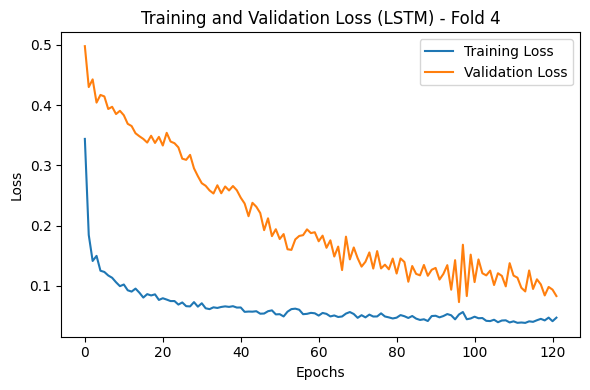

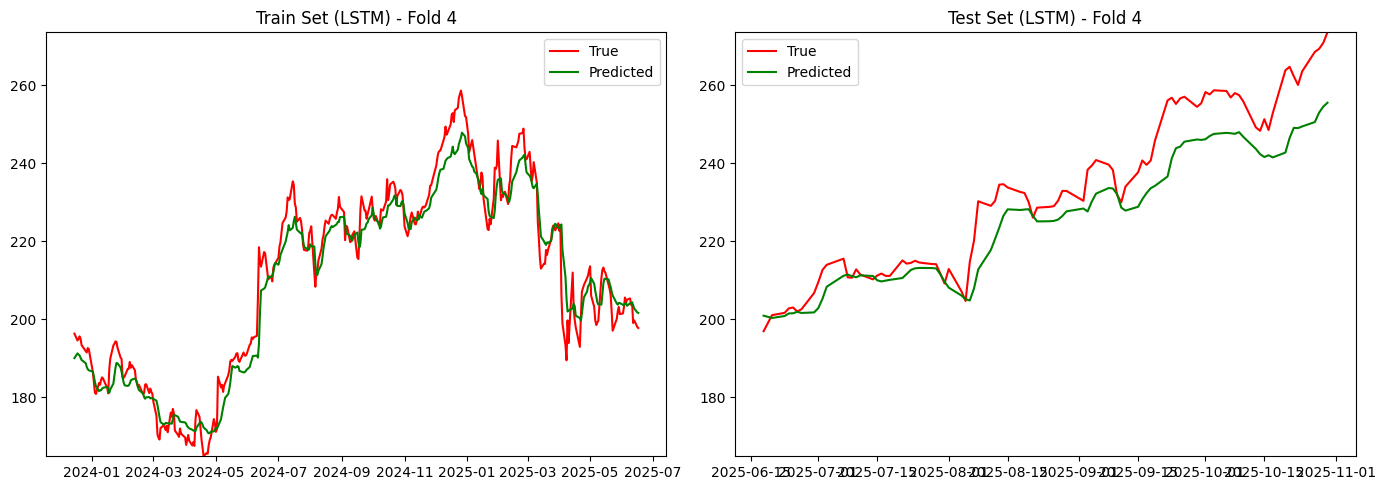

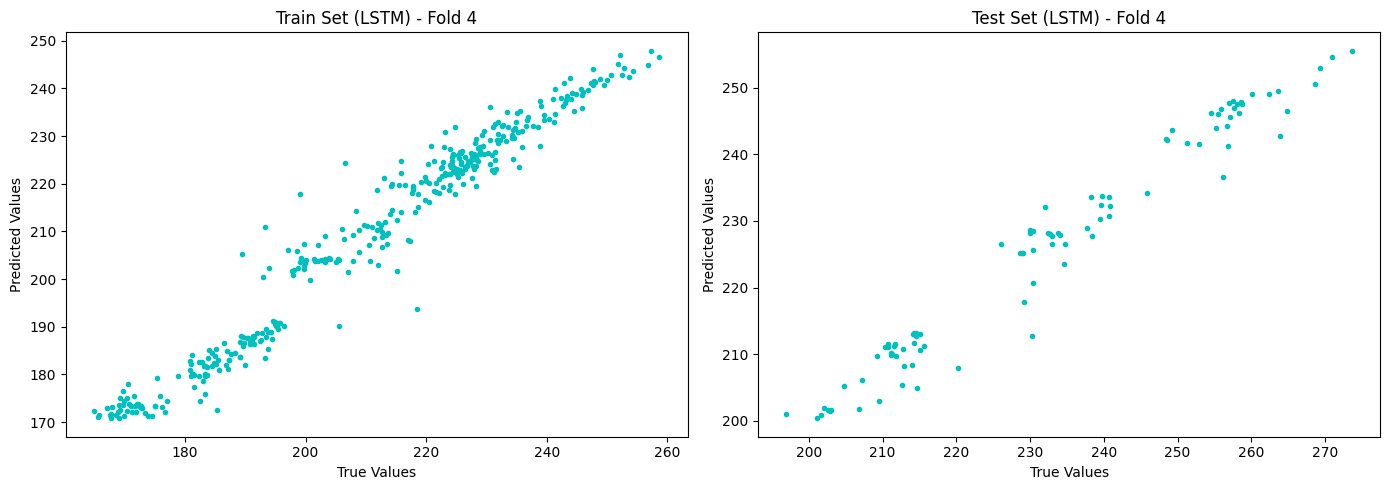

In [57]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Define the LSTM model building function
def build_lstm_model(window_size, num_features, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential([
        Input(shape=(window_size, num_features)),
        LSTM(64, return_sequences=True),
        Dropout(dropout_rate),
        BatchNormalization(),
        LSTM(32, return_sequences=False),
        Dropout(dropout_rate),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mae')
    return model

# Re-initialize TimeSeriesSplit
n_splits = 5
kf_time_series = TimeSeriesSplit(n_splits=n_splits)

# X_recent_2d was already created in cell 5fe8341e
# We will iterate to get the 4th fold's indices

selected_fold = 4
current_fold = 0

for train_index, test_index in kf_time_series.split(X_recent_2d):
    current_fold += 1
    if current_fold == selected_fold:
        # Store the indices for the selected fold
        train_index_4 = train_index
        test_index_4 = test_index
        break

print(f"Extracted indices for Fold {selected_fold}")

# Extract data for Fold 4
X_train_fold_4_2d = X_recent_2d[train_index_4]
X_test_fold_4_2d  = X_recent_2d[test_index_4]
y_train_fold_4    = y_recent[train_index_4]
y_test_fold_4     = y_recent[test_index_4]
dates_train_fold_4 = dates_recent[train_index_4]
dates_test_fold_4  = dates_recent[test_index_4]

# Scale data for Fold 4
scaler_X_fold_4 = MinMaxScaler(feature_range=(0, 1))
scaler_y_fold_4 = MinMaxScaler(feature_range=(0, 1))

X_train_scaled_fold_4_2d = scaler_X_fold_4.fit_transform(X_train_fold_4_2d)
X_test_scaled_fold_4_2d  = scaler_X_fold_4.transform(X_test_fold_4_2d)

y_train_scaled_fold_4 = scaler_y_fold_4.fit_transform(y_train_fold_4.reshape(-1, 1))
y_test_scaled_fold_4  = scaler_y_fold_4.transform(y_test_fold_4.reshape(-1, 1))

# Reshape scaled X data to 3D for LSTM input
current_window_size = X_recent.shape[1] # This should be 10
current_num_features = X_recent.shape[2] # This should be 5

X_train_scaled_3d_fold_4 = X_train_scaled_fold_4_2d.reshape((X_train_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))
X_test_scaled_3d_fold_4  = X_test_scaled_fold_4_2d.reshape((X_test_scaled_fold_4_2d.shape[0], current_window_size, current_num_features))

print("Data for Fold 4 prepared and scaled.")

# Build a fresh model for Fold 4
model_lstm_fold_4 = build_lstm_model(
    current_window_size,
    current_num_features,
    dropout_rate=0.2,
    learning_rate=0.001 # Use the optimized learning rate
)

# Early stopping callback
early_stopping_fold_4 = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

print(f"\nTraining model for Fold {selected_fold}...")
history_lstm_fold_4 = model_lstm_fold_4.fit(
    X_train_scaled_3d_fold_4, y_train_scaled_fold_4,
    epochs=250,
    batch_size=64,
    validation_data=(X_test_scaled_3d_fold_4, y_test_scaled_fold_4),
    verbose=1,
    callbacks=[early_stopping_fold_4]
)

print(f"\nEvaluation for Fold {selected_fold}:")
# Get predictions
y_train_pred_scaled_fold_4 = model_lstm_fold_4.predict(X_train_scaled_3d_fold_4)
y_test_pred_scaled_fold_4  = model_lstm_fold_4.predict(X_test_scaled_3d_fold_4)

# Inverse transform predictions to original scale
y_train_pred_fold_4 = scaler_y_fold_4.inverse_transform(y_train_pred_scaled_fold_4)
y_test_pred_fold_4  = scaler_y_fold_4.inverse_transform(y_test_pred_scaled_fold_4)

# Calculate metrics
r2_train_fold_4 = r2_score(y_train_fold_4, y_train_pred_fold_4)
r2_test_fold_4  = r2_score(y_test_fold_4, y_test_pred_fold_4)

rmse_train_fold_4 = mean_squared_error(y_train_fold_4, y_train_pred_fold_4)**0.5
rmse_test_fold_4  = mean_squared_error(y_test_fold_4, y_test_pred_fold_4)**0.5

mae_train_fold_4 = mean_absolute_error(y_train_fold_4, y_train_pred_fold_4)
mae_test_fold_4  = mean_absolute_error(y_test_fold_4, y_test_pred_fold_4)

print("MAE:")
print(f"  Train: {mae_train_fold_4:.4f}")
print(f"  Test:  {mae_test_fold_4:.4f}")
print("R^2:")
print(f"  Train: {r2_train_fold_4:.4f}")
print(f"  Test:  {r2_test_fold_4:.4f}")

# Plotting for Fold 4
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.plot(history_lstm_fold_4.history['loss'], label='Training Loss')
ax.plot(history_lstm_fold_4.history['val_loss'], label='Validation Loss')
ax.set_title(f'Training and Validation Loss (LSTM) - Fold {selected_fold}')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

y_train_pred_series_fold_4 = pd.Series(y_train_pred_fold_4.flatten(), index=dates_train_fold_4)
y_test_pred_series_fold_4  = pd.Series(y_test_pred_fold_4.flatten(), index=dates_test_fold_4)

y_min_fold_4 = min(y_train_fold_4.min(), y_train_pred_series_fold_4.min(), y_test_fold_4.min(), y_test_pred_series_fold_4.min())
y_max_fold_4 = max(y_train_fold_4.max(), y_train_pred_series_fold_4.max(), y_test_fold_4.max(), y_test_pred_series_fold_4.max())

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(dates_train_fold_4, y_train_fold_4, 'r', label='True')
axs[0].plot(y_train_pred_series_fold_4, 'g', label='Predicted')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_ylim(y_min_fold_4, y_max_fold_4)
axs[0].legend()

axs[1].plot(dates_test_fold_4, y_test_fold_4, 'r', label='True')
axs[1].plot(y_test_pred_series_fold_4, 'g', label='Predicted')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_ylim(y_min_fold_4, y_max_fold_4)
axs[1].legend()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(y_train_fold_4, y_train_pred_series_fold_4.values, 'c.')
axs[0].set_title(f'Train Set (LSTM) - Fold {selected_fold}')
axs[0].set_xlabel('True Values')
axs[0].set_ylabel('Predicted Values')

axs[1].plot(y_test_fold_4, y_test_pred_series_fold_4.values, 'c.')
axs[1].set_title(f'Test Set (LSTM) - Fold {selected_fold}')
axs[1].set_xlabel('True Values')
axs[1].set_ylabel('Predicted Values')

plt.tight_layout()
plt.show()

### Saving the Trained Model for Specific Fold (e.g., Fold 4)

Now, we will save the `model_lstm_fold_4` which was specifically trained and evaluated on **Fold 4**. This allows you to retain the model's weights and configuration from this particular cross-validation split.

In [58]:
import joblib
model_lstm_fold_4.save('lstm_model_fold_4.keras')
print("LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'")

# Save the X scaler specific to Fold 4
joblib.dump(scaler_X_fold_4, 'scaler_X_fold_4.pkl')
print("X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'")

# Save the y scaler specific to Fold 4
joblib.dump(scaler_y_fold_4, 'scaler_y_fold_4.pkl')
print("Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'")

LSTM model for Fold 4 saved as 'lstm_model_fold_4.keras'
X scaler for Fold 4 saved as 'scaler_X_fold_4.pkl'
Y scaler for Fold 4 saved as 'scaler_y_fold_4.pkl'


### Saving the Trained Model and Scalers

Now, we will save the retrained LSTM model (`lstm_model.keras`), the fitted X-scaler (`scaler_X.pkl`), and the fitted y-scaler (`scaler_y.pkl`) to your project directory. These files can be loaded later to make new predictions without retraining or re-fitting the scalers.

In [ ]:
# Save the LSTM model
model_lstm_final.save('lstm_model.keras')
print("LSTM model saved as 'lstm_model.keras'")

# Save the X scaler
joblib.dump(scaler_X_final, 'scaler_X.pkl')
print("X scaler saved as 'scaler_X.pkl'")

# Save the y scaler
joblib.dump(scaler_y_final, 'scaler_y.pkl')
print("Y scaler saved as 'scaler_y.pkl'")

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(predicted_results_df_corrected['Percentage Error (%)'], bins=50, kde=True)
plt.title('Distribution of Percentage Error (%) for LSTM Model Predictions')
plt.xlabel('Percentage Error (%)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()